In [ ]:
# Implement Simple Naïve Bayes classification algorithm using Python/R on iris.csv dataset.
# Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_squared_error

In [ ]:
df=pd.read_csv("iris.csv")
df.head()

,Id,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,1,5.1,3.5,1.4,0.2,Setosa
1,2,4.9,3.0,1.4,0.2,Setosa
2,3,4.7,3.2,1.3,0.2,Setosa
3,4,4.6,3.1,1.5,0.2,Setosa
4,5,5.0,3.6,1.4,0.2,Setosa


In [ ]:
df.isnull().sum()

,0
Id,0
SepalLength,2
SepalWidth,0
PetalLength,0
PetalWidth,2
Species,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.head()

,Id,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,1,5.1,3.5,1.4,0.2,Setosa
1,2,4.9,3.0,1.4,0.2,Setosa
2,3,4.7,3.2,1.3,0.2,Setosa
3,4,4.6,3.1,1.5,0.2,Setosa
4,5,5.0,3.6,1.4,0.2,Setosa


In [ ]:
df.describe()

,Id,SepalLength,SepalWidth,PetalLength,PetalWidth
count,146.000000,146.000000,146.000000,146.000000,146.000000
mean,76.383562,5.857534,3.049315,3.791781,1.213014
std,43.281478,0.827029,0.435058,1.749424,0.754414
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,40.250000,5.100000,2.800000,1.600000,0.300000
50%,76.500000,5.800000,3.000000,4.400000,1.300000
75%,113.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.columns

Index(['Id', 'SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth',
       'Species'],
      dtype='object')

In [ ]:
X=df.iloc[:,:4].values
Y=df["Species"].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train ,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)


In [ ]:
from sklearn.naive_bayes import GaussianNB
classifier=GaussianNB()
classifier.fit(X_train,y_train)

GaussianNB()

In [ ]:
y_pred = classifier.predict(X_test)
y_pred

array(['Virginica', 'Versicolor', 'Virginica', 'Setosa', 'Setosa',
       'Versicolor', 'Versicolor', 'Versicolor', 'Setosa', 'Setosa',
       'Virginica', 'Versicolor', 'Setosa', 'Versicolor', 'Virginica',
       'Virginica', 'Virginica', 'Virginica', 'Setosa', 'Versicolor',
       'Setosa', 'Virginica', 'Setosa', 'Setosa', 'Versicolor', 'Setosa',
       'Setosa', 'Virginica', 'Versicolor', 'Versicolor'], dtype='<U10')

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

In [ ]:
cm

array([[11,  0,  0],
       [ 0,  8,  0],
       [ 0,  2,  9]])

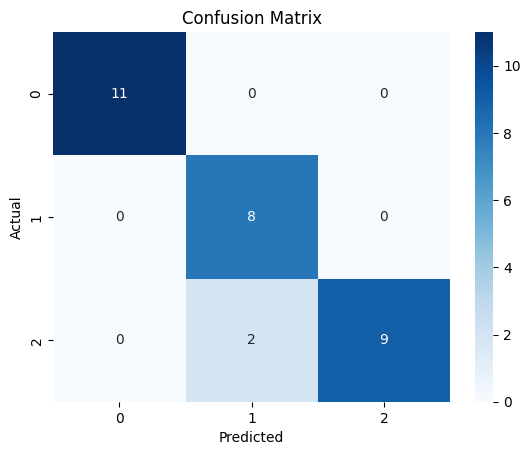

In [ ]:
# Confusion Matrix Graphical Representation
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Classification Record
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        11
  Versicolor       0.80      1.00      0.89         8
   Virginica       1.00      0.82      0.90        11

    accuracy                           0.93        30
   macro avg       0.93      0.94      0.93        30
weighted avg       0.95      0.93      0.93        30

